## Look for Extremes in Todays Salish Sea compared to the Climatology 2007-2025 ##

In [29]:
import cmocean.cm as cm
import copy
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import xarray as xr

from salishsea_tools import viz_tools

In [30]:
plt.rcParams['font.size'] = 15
cm_haline = copy.copy(cm.haline)
cm_haline.set_bad('k')

In [31]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = mesh['tmask'][0]
deptht = mesh['gdept_1d'][0]

In [32]:
salishdir = Path('/results2/SalishSea/nowcast-green.202111/')

In [33]:
# set up dates
yearrange = [2007, 2025]
thisyear = 2026
today = dt.datetime(2026, 3, 26)

In [34]:
dirstring = today.strftime("%d%b%y").lower()
timestring = f'{today.year}{today.month:02d}{today.day:02d}'
datafilen = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')

In [35]:
nfields = 2
fields = ['vosaline', 'votemper']

In [36]:
# set up the subset of the spatial array to investigate
step = 5
slice_x = slice(0, 398, step)
slice_y = slice(0, 898, step)
slice_z = slice(0, 40, step)

In [37]:
nz, ny, nx = datafilen[fields[0]][0, slice_z, slice_y, slice_x].shape

In [38]:
history = np.zeros((nfields, yearrange[1] - yearrange[0] + 1, nz, ny, nx))
now = np.zeros_like(history[:, 0])

In [39]:
number_values = tmask[slice_z, slice_y, slice_x].sum(axis=2).sum(axis=1).values
number_values

array([3257, 3204, 3099, 2981, 2790, 2101,  844,  281])

In [40]:
def mymask(array, dl, nfields):
    maskedarray = np.ma.array(array, mask=0)
    if nfields > 1:
        for kf in range(nfields):
            maskedarray[kf] = np.ma.array(array[kf], mask=1-tmask[dl*step, ::step, ::step])
    else:
        maskedarray = np.ma.array(array, mask=1-tmask[dl*step, ::step, ::step])
    return maskedarray

In [41]:
for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
    dirstring = dt.datetime(year, today.month, today.day).strftime("%d%b%y").lower()
    timestring = f'{year}{today.month:02d}{today.day:02d}'
    datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
    for kf, field in enumerate(fields):
        history[kf, iy] = datafile[field][0, ::step, ::step, ::step]
    datafile.close()

In [42]:
for kf, field in enumerate(fields):
    now[kf] = datafilen[field][0, ::step, ::step, ::step]
datafile.close()

In [43]:
max_values = mymask(history.max(axis=1), np.arange(nz), nfields)
min_values = mymask(history.min(axis=1), np.arange(nz), nfields)
median_values = mymask(np.median(history, axis=1), np.arange(nz), nfields)
high_values = mymask(np.quantile(history, 0.75, axis=1), np.arange(nz), nfields)
low_values = mymask(np.quantile(history, 0.25, axis=1), np.arange(nz), nfields)

In [44]:
min_mask = now < min_values
max_mask = now > max_values
lower_mask = now < median_values
upper_mask = now > median_values
low_mask = now < low_values
high_mask = now > high_values

In [45]:
def myravel(index, nz):
    kf = index // nz
    dl = index - kf*nz
    return [kf, dl]

696


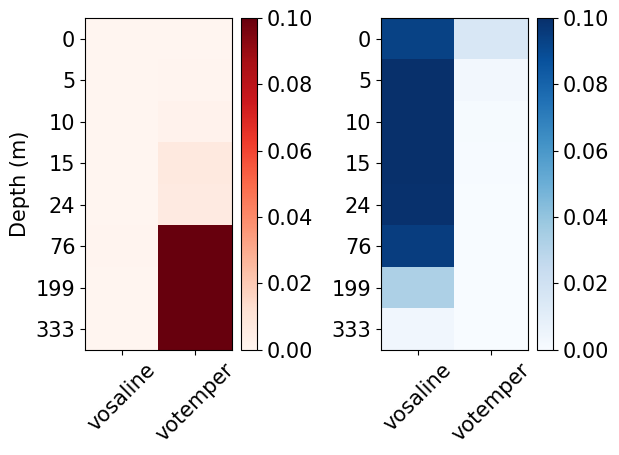

In [46]:
now_values = mymask(now, np.arange(nz), nfields)
extreme_high = (now_values - max_values) / (high_values-low_values)
extreme_high.mask[extreme_high <= 0] = True
print (extreme_high.count())
how_extreme_high = extreme_high.count(axis=3).sum(axis=2)/number_values
zmaxhigh = myravel(np.argmax(how_extreme_high), nz)

extreme_low = (min_values - now_values) / (high_values-low_values)
extreme_low.mask[extreme_low <= 0] = True
how_extreme_low = extreme_low.count(axis=3).sum(axis=2)/number_values
zmaxlow = myravel(np.argmax(how_extreme_low), nz)

fig, axs = plt.subplots(1, 2)
colours = axs[0].pcolormesh(how_extreme_high.transpose(), cmap='Reds', vmax=0.1)
fig.colorbar(colours, ax=axs[0])
colours = axs[1].pcolormesh(how_extreme_low.transpose(), cmap='Blues', vmax=0.1)
fig.colorbar(colours, ax=axs[1])

for ax in axs:
    ax.invert_yaxis()
    ax.set_xticks([0.5, 1.5], fields, rotation=45)
    ax.set_yticks(np.arange(nz)+0.5, (deptht[np.arange(nz)*step].values).astype(int))

axs[0].set_ylabel('Depth (m)')
fig.tight_layout();

In [47]:
print (how_extreme_high.shape)

(2, 8)


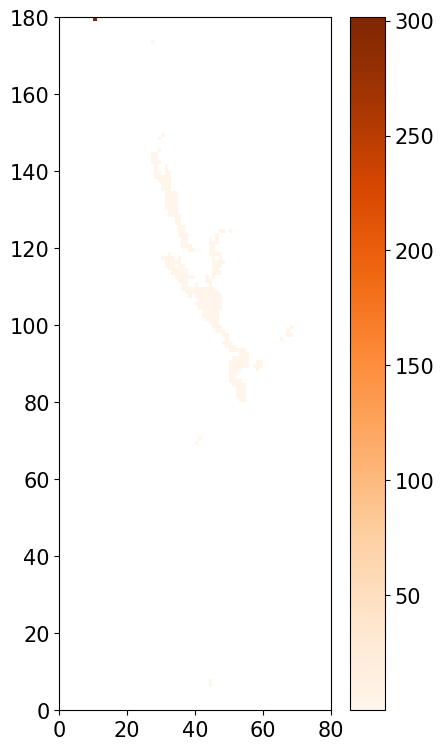

In [48]:
if how_extreme_high[zmaxhigh[0], zmaxhigh[1]] > how_extreme_low[zmaxlow[0], zmaxlow[1]]:
    extreme = 'high'
else:
    extreme = 'low'
    print (extreme, zmaxlow)
    
fig, ax = plt.subplots(1, 1, figsize=(5, 9))
if extreme == 'low':
    ax.pcolormesh(tmask[zmaxlow[1]*step, ::step, ::step], cmap='binary_r')
    colours = ax.pcolormesh(extreme_low[zmaxlow[0], zmaxlow[1]], cmap='Oranges')
else:
#    ax.pcolormesh(tmask[zmaxhigh[1]*step, ::step, ::step], cmap='binary_r')
    colours = ax.pcolormesh(extreme_high[zmaxhigh[0], zmaxhigh[1]], cmap='Oranges')
fig.colorbar(colours, ax=ax)
viz_tools.set_aspect(ax);

In [49]:
def nine_plot(kf, dl):
    fig, axs = plt.subplots(3, 3, figsize=(15, 27))
    field = fields[kf]
    print (f'Depth is {deptht[dl*step].values} and field is {field}')
    
    if field == 'vosaline':
        cmap = cm.haline
    elif field == 'votemper':
        cmap = cm.thermal
    
    alpha = 0.25
    needed = max_values[kf, dl]
    vmax = np.nanmax(needed[needed !=0])
    needed = min_values[kf, dl]
    vmin = np.nanmin(needed[needed !=0])
    
    for ax in axs.flatten():
        ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')
    
    # First Row
    colours = axs[0, 0].pcolormesh(mymask(max_values[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 0]);
    axs[0, 0].set_title('Maximum Values')
    
    colours = axs[0, 1].pcolormesh(mymask(min_values[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 1]);
    axs[0, 1].set_title('Minimum Values')
    
    colours = axs[0, 2].pcolormesh(mymask(now[kf, dl], dl, 1), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 2])
    axs[0, 2].set_title(f'{today}')
    
    # Second Row
    colours = axs[1, 0].pcolormesh(np.ma.array(now[kf, dl], mask=1-upper_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[1, 0].pcolormesh(mymask(now[kf, dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    fig.colorbar(colours, ax=axs[1, 0])
    axs[1, 0].set_title('Above Median')

    axs[1, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-high_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[1, 1])
    axs[1, 1].set_title('Upper Quartile')
    
    axs[1, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 2].pcolormesh(np.ma.array(now[kf,dl],mask=1-max_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[1, 2].set_title('New Maximum');
    fig.colorbar(colours, ax=axs[1, 2]);
    
    # Third Row
    axs[2, 0].pcolormesh(mymask(now[kf,dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    colours = axs[2, 0].pcolormesh(np.ma.array(now[kf, dl],mask=1-lower_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 0])
    axs[2, 0].set_title('Below Median')
    
    axs[2, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-low_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 1])
    axs[2, 1].set_title('Lower Quartile')
    
    axs[2, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 2].pcolormesh(np.ma.array(now[kf,dl],mask=1-min_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[2, 2].set_title('New Minimum');
    fig.colorbar(colours, ax=axs[2, 2]);
    
    for ax in axs.flatten():
            viz_tools.set_aspect(ax)

Depth is 199.57304923038515 and field is votemper


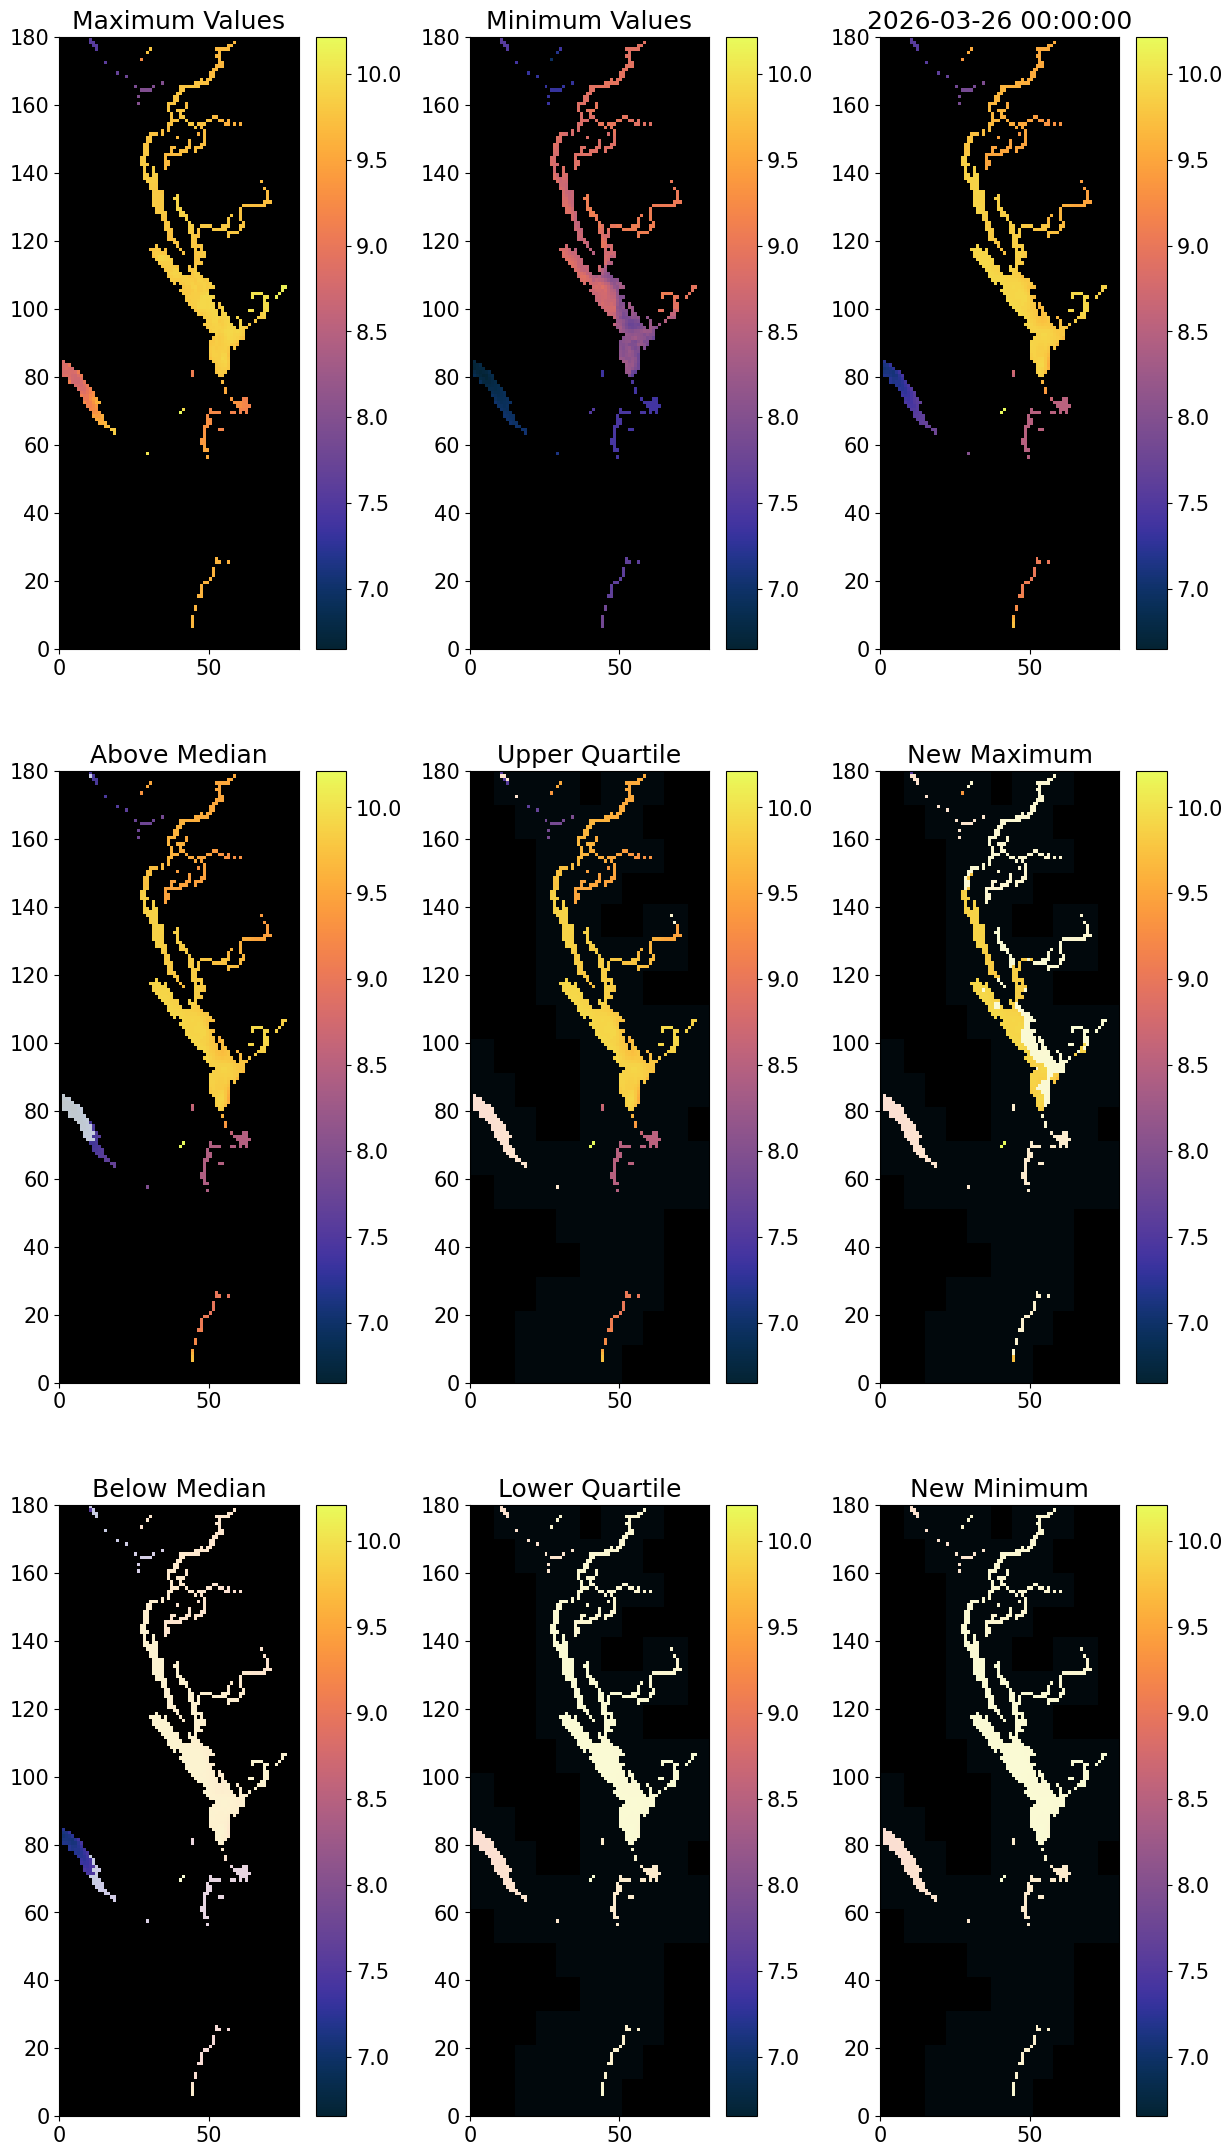

In [50]:
if extreme == 'low':
    dl = zmaxlow[1]
    kf = zmaxlow[0]
else:
    dl = zmaxhigh[1]
    kf = zmaxhigh[0]
nine_plot(kf, dl)

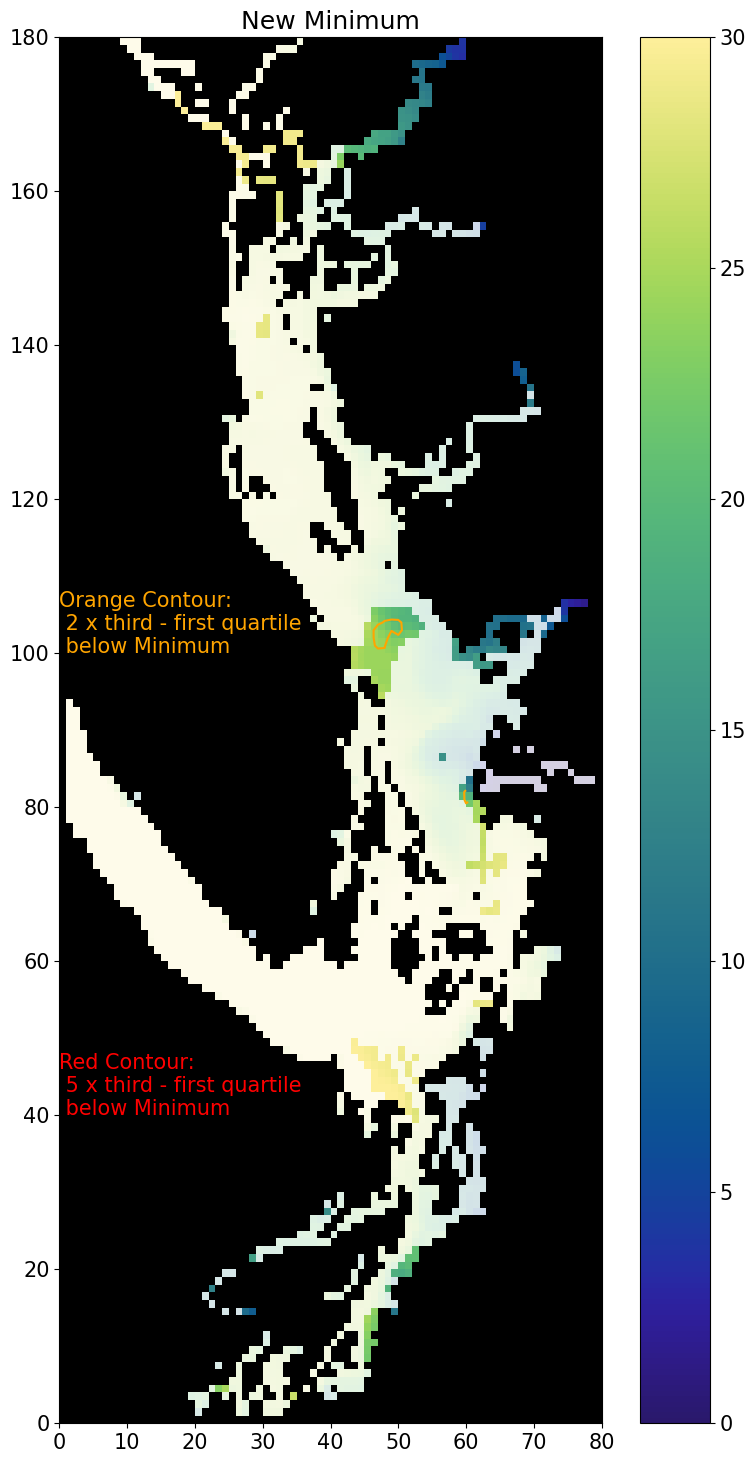

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 18))
dl = 0
ax.pcolormesh(tmask[dl*step, slice_y, slice_x], cmap='binary_r')
ax.pcolormesh(now_values[0, dl], vmax=30, alpha=0.2, cmap=cm.haline)
colours = ax.pcolormesh(np.ma.array(now[0, dl],mask=1-min_mask[0, dl]), vmin=0, vmax=30, cmap=cm.haline)
ax.set_title('New Minimum');
fig.colorbar(colours, ax=ax);
ax.contour(extreme_low[0, dl], [2, 5], colors=['orange', 'r'])
ax.text(0, 500/step, 'Orange Contour:\n 2 x third - first quartile\n below Minimum', color='orange')
ax.text(0, 200/step, 'Red Contour:\n 5 x third - first quartile\n below Minimum', color='r')

viz_tools.set_aspect(ax);

In [52]:
# a point 120, 250
def plot_cross(kf, dl, ii=int(500/step), js=int(160/step), je = int(290/step)):

    fig, ax = plt.subplots(1, 1)
    ax.plot(now_values[kf, dl, ii, js:je])
    ax.plot(median_values[kf, dl, ii, js:je], linewidth=3)
    ax.plot(low_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(min_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(high_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(max_values[kf, dl, ii, js:je], c='tab:orange');
    ax.set_title(f'Across Strait North of Gabriola, depth = {deptht[dl*step].values} for {fields[kf]}');

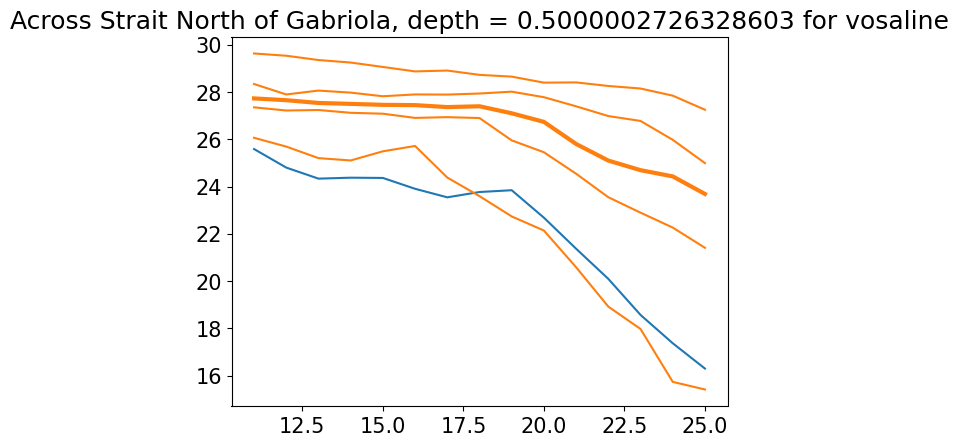

In [53]:
plot_cross(0, 0)

In [ ]:
nine_plot(1, 6)

Depth is 199.57304923038515 and field is votemper


In [ ]:
plot_cross(1, 6, ii=110)